In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm

In [3]:


data = pd.read_csv('Preços_de_casas.csv')

Precificação valores de um casa utilizando regressão linear.
Utilizaremos conceitos de amostragem de dados e análise exploratória de dados.
Identificar como como algumas variáveis influenciam no valor de venda de uma casa.

In [4]:
# Quais são os fatores que foram coletados a partir dos dados carregadO?
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [5]:
data = data.drop(columns='Id')

In [6]:
# correlação dos vatores

corr = data.corr()

Intensidade: Refere-se à força da relação entre as variáveis medidas. 

- Pode variar de -1 a +1, onde -1 indica uma correlação perfeitamente negativa, +1 indica uma correlação perfeitamente positiva e 0 indica ausência de correlação linear.

        
Direção: Refere-se à natureza da relação entre as variáveis medidas. 

- Uma correlação positiva indica que as variáveis aumentam ou diminuem juntas. 
        
- Uma correlação negativa indica que uma variável aumenta enquanto a outra diminui, ou vice-versa.

In [7]:
# Para cada uma das colunas do conjunto, iremos retornar a correlação com a coluna de "preço de venda"
# quanto mais próximo dos extremos, mais correlacionado as variáveis estão com a variável analisada
#
corr['preco_de_venda']

area_primeiro_andar               0.616557
existe_segundo_andar              0.138541
area_segundo_andar                0.305311
quantidade_banheiros              0.563132
capacidade_carros_garagem         0.640214
qualidade_da_cozinha_Excelente    0.496223
preco_de_venda                    1.000000
Name: preco_de_venda, dtype: float64

Analizando o coeficiente de correlação linear entre as variáveis "capacidade_carros_garagem" e "preco_de_venda":

- Intensidade: O coeficiente de correlação linear é de 0.64, indicando uma correlação moderadamente forte; 

- direção: No geral, a medida que a capacidade de carros da garagem de uma casa aumenta, seu preço também tende a aumentar 

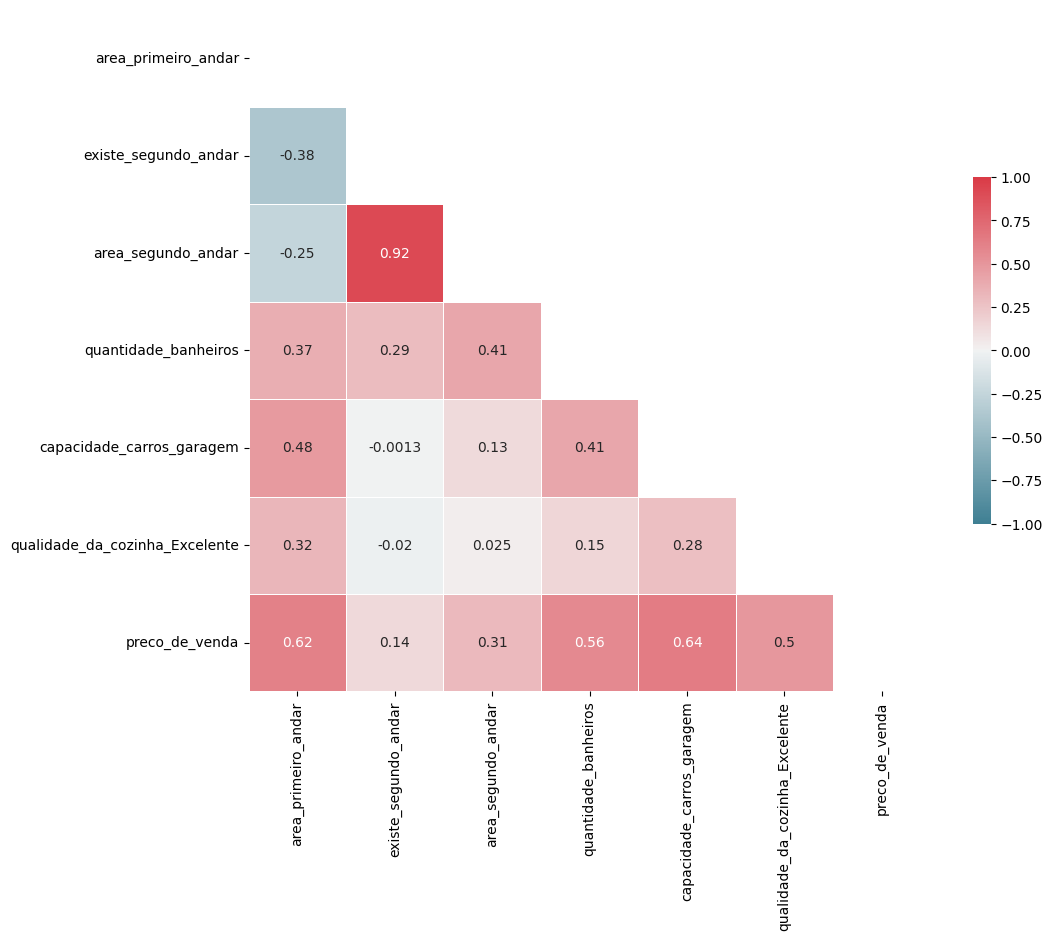

In [8]:
# Gerar uma máscara para o triângulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar a figura do matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Gerar o mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

# Exibir o mapa de calor (heatmap)
plt.show()

In [9]:
%pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Text(0, 0.5, 'Preço de venda')

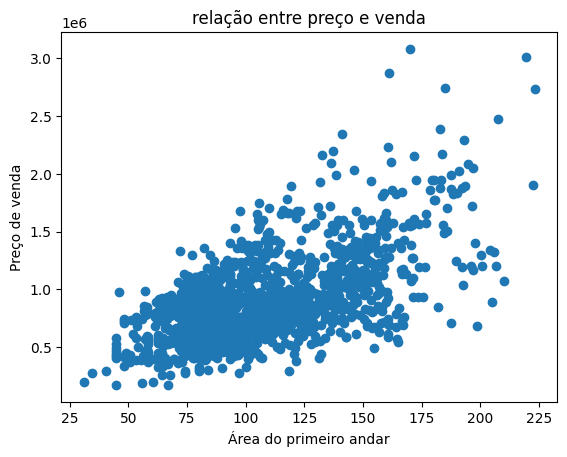

In [10]:
# aparentemente, quanto maior a area do primeiro andar, maior é o preço da casa.

plt.scatter(x = data['area_primeiro_andar'], y = data ['preco_de_venda'])

plt.title("relação entre preço e venda")
plt.xlabel("Área do primeiro andar")
plt.ylabel("Preço de venda")


Text(0, 0.5, 'Preço de venda')

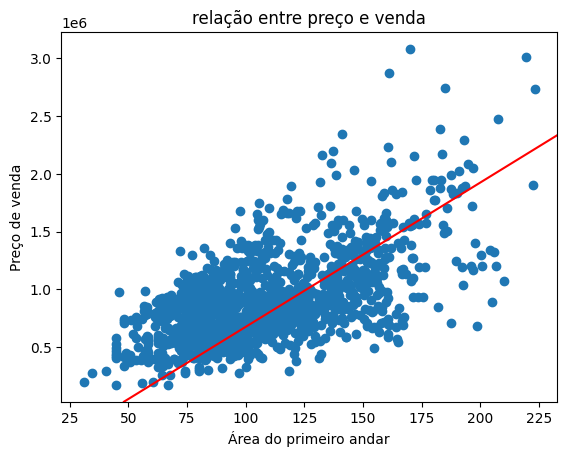

In [11]:
plt.scatter(x = data['area_primeiro_andar'], y = data ['preco_de_venda'])

# Abaixo traças uma linha através da marcação de dois pontos no gráfico, utilizando as coordenadas x e y.
# Os valores atribuídos são arbitrários e, nesse caso, são utilizados para analizar esses pontos
plt.axline(xy1 = (66,250000), xy2= (190, 1800000), color = "red")

plt.title("relação entre preço e venda")
plt.xlabel("Área do primeiro andar")
plt.ylabel("Preço de venda")

In [12]:
# Qual é a melhor reta que representa os meus dados?

px.scatter(data, x = "area_primeiro_andar", y = 'preco_de_venda', trendline_color_override= 'red', trendline= 'ols')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'area_primeiro_andar=%{x}<br>preco_de_venda=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'x': array([ 79.5224, 117.2398,  85.468 , ..., 110.3652, 100.1462, 116.6824],
                         shape=(1438,)),
              'xaxis': 'x',
              'y': array([1027905.  ,  894795.  , 1101855.  , ..., 1313845.  ,  700676.25,
                           727175.  ], shape=(1438,)),
              'yaxis': 'y'},
             {'hovertemplate': ('<b>OLS trendline</b><br>preco_' ... ' <b>(trend)</b><extra></extra>'),
              'legendgroup': '',
              'line': {'color': 'red'},
              'marker': {'color': '#636efa', 'symbol': 'circle'},
              'mode': 'lines',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'x': array([ 31.0286,  34.5588,  40.6902, ..., 219.6156, 222.2168, 223.1458],
                         shape=(1438,)),
              'xaxis': 'x',
              'y': array([ 358849.30911813,  383204.85024705,  425506.57957624, ...,
                          1659947.95363708, 1677894.14183734, 1684303.49476601], shape=(1438,)),
              'yaxis': 'y'}],
    'layout': {'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'area_primeiro_andar'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'preco_de_venda'}}}
})

-  Elencamos uma variável explicativa
- Elencamos uma variável 
- a representação linear possuyi uma formula que é Yi = Bo + B1*Xi
- Com isso, podemos definir o preço de venda a partir da área do primeiro andar

O QUE APRENDI ATÉ AQUI:
- Obter o coeficiente de correlação dos dados;
- Analisar a intensidade e a direção da correlação entre duas variáveis;
- Identificar linearidade no gráfico de dispersão;
- Diferenciar variável explicativa de variável resposta;
- Visualizar a melhor reta utilizando o Plotly.

## Explicando a reta 

Ajustamos uma reta entre o metro quadrado do primeiro andar e o preço da casa. Queremos explicar o preço da casa a partir do seu tamanho, por isso, dizemos que:

- Variável explicativa/independente: Área do primeiro andar;
- Variável resposta/dependente: Preço da casa


#### Separando em treino e teste

O conjunto de **treinamento** é usado para ajustar modelos de ML. o conjunto de **Teste** é usado para avaliar a acurávia do algorítmo em prever o preço de venda de casas oriundas de um novo conjunto de dados.

In [13]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
# import train test split

from sklearn.model_selection import train_test_split


In [15]:
y = data['preco_de_venda']
x = data.drop(columns='preco_de_venda')

In [16]:
# criando a separação entre o treino e teste
# o train_test_split retorna 4 variáveis.

x_train, x_test, y_train, y_teste = train_test_split(x, y, test_size = 0.3, random_state=230 )

In [17]:
df_train = pd.DataFrame(data = x_train)
df_train['preco_de_venda'] = y_train


In [18]:
from statsmodels.formula.api import ols

In [19]:
modelo_0 = ols('preco_de_venda ~ area_primeiro_andar', data = df_train).fit()

#### Analisando os coeficientes

Intencidade, direção e signfiicância

In [20]:
# Visualização os parâmetros
# se a área da casa for zero e ainda nao foi construída, identificamos que o preço dela em média será o da variável intercept retornada pela função abaixo


modelo_0.params

Intercept              152909.288334
area_primeiro_andar      6793.641641
dtype: float64

In [21]:
# Acessando o resumno do modelo

print(modelo_0.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Tue, 24 Dec 2024   Prob (F-statistic):          2.22e-105
Time:                        14:01:43   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.529e+05   3

##### A regressão linear foi a metodologia que ajustou a melhor reta que representa linearmente a interação entre X e Y; no nosso caso, o tamanho da área do primeiro andar e o preço de venda da casa.

##### Y = β₀ + (β₁).(x) + e

- **Variável Resposta (Y)**: Também chamada de variável dependente é aquela que estamos tentando prever.

- **Intercepto (β₀)**: O ponto onde a linha de regressão intercepta o eixo vertical (Y), ou seja, o valor de Y quando X é igual a 0.

- **Variável Explicativa (X)**: Também chamada de variável independente e é o fator que usamos para prever e explicar a variável resposta.

- **Coeficientes de Regressão (β₁)**: Impacto de cada variável explicativa X na variável resposta, é o efeito de X em Y.

- **Erro Residual (e)**: Diferença entre os valores reais e previstos da variável resposta.

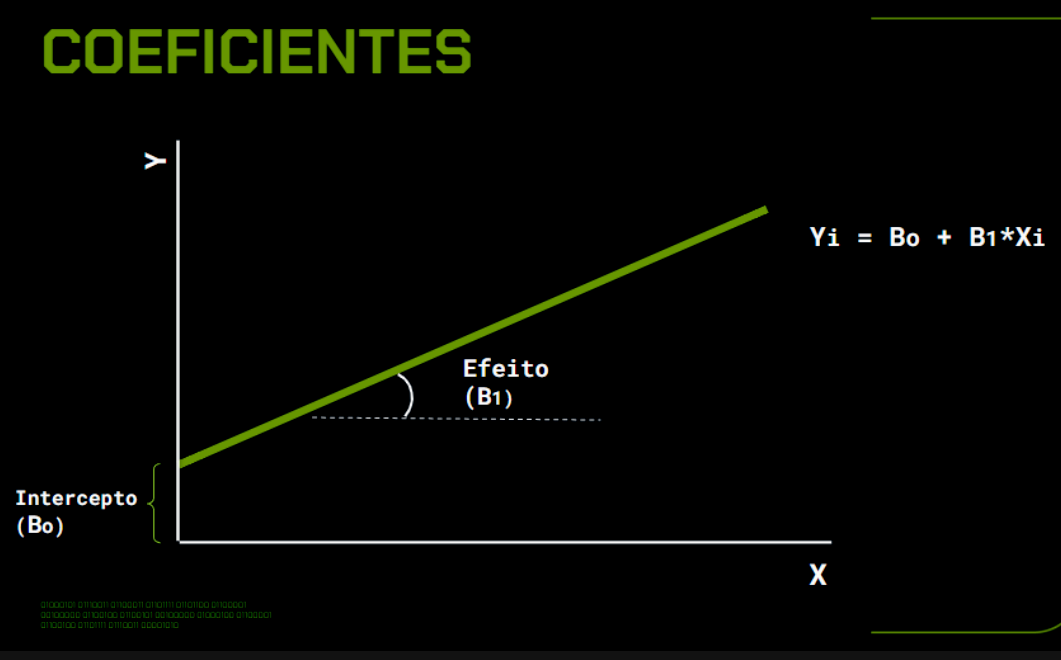

##### Será que ometro quadrado é suficiente para explicar o preço da casa?

Precisamos recorrer a variável R², o coeficiente de **determinação**. O R² varia de 0 a 1, onde 1 indica que um ajuste perfeito no modelo de dados, ou seja, todas as variações na variável dependente são explicadas pelas variáveis indeptendentes do modelo.

Se o R² está em zero, isso indica que o modelo não explica nanhuma variabiabilidade na variável independente.

In [22]:
# Nesse caso, um R² próximo de 0 indica que somente a variável x, área da casa, não explica tototalmente a variável preço de venda, que é o y da função
modelo_0.rsquared

np.float64(0.3772801099429788)

##### Entendendo o Resíduo

Os residuos são a a diferenca entre a reta traçada pelo modelo (que é uma predição média) e a observação da realidade, isto é, o quão longe a predição está longe dos valores reais.

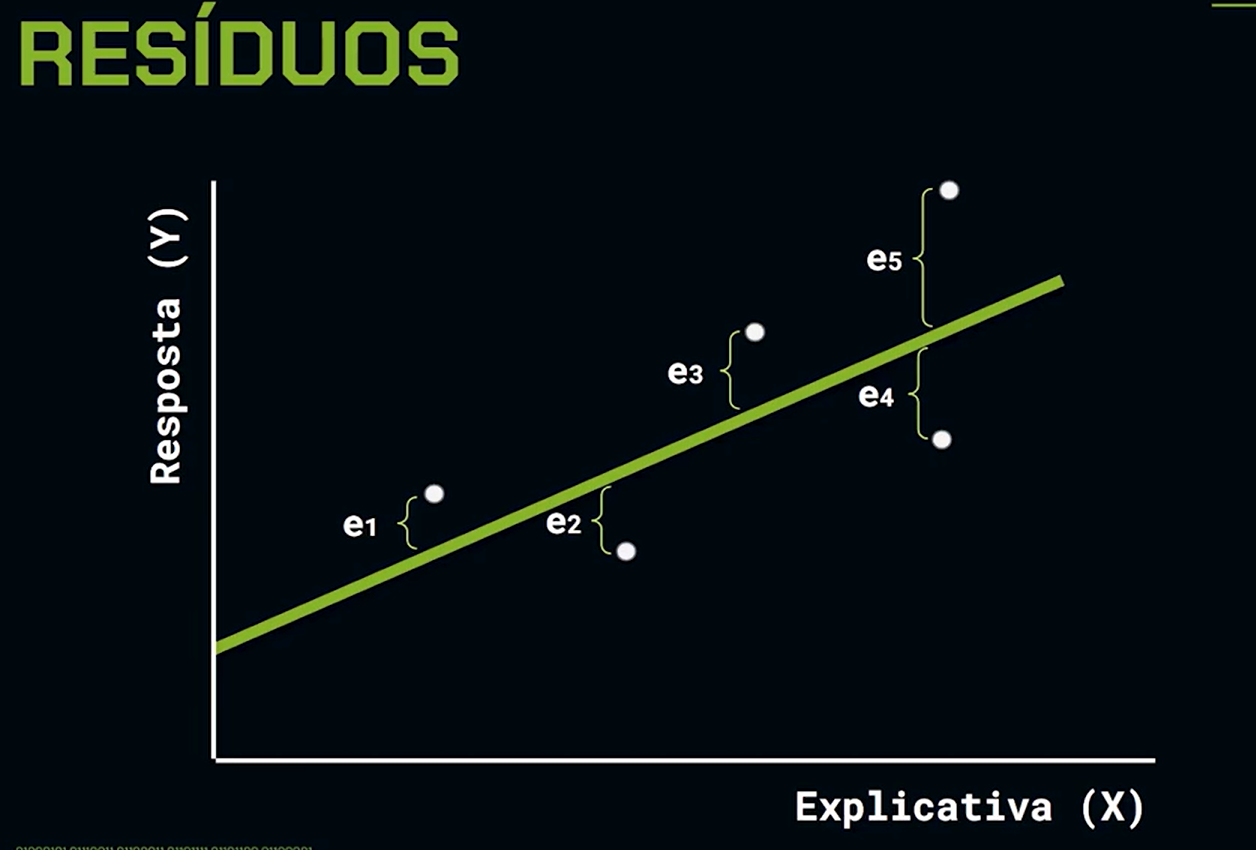

In [29]:
modelo_0.resid

1303   -193023.838744
326    -144522.356193
386     399612.747641
615     -68449.596607
236     166010.592859
            ...      
777     465872.680999
271    -497642.319788
723     461150.204718
560    -540482.733402
768     -37547.820756
Length: 1006, dtype: float64

Text(0.5, 1.0, 'distribuição dos resíduos')

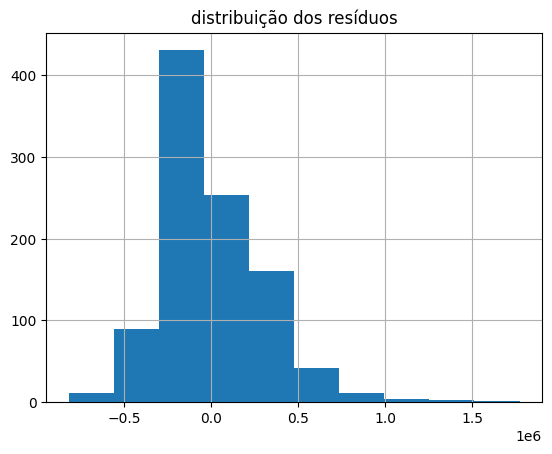

In [30]:
modelo_0.resid.hist()

plt.title("distribuição dos resíduos")

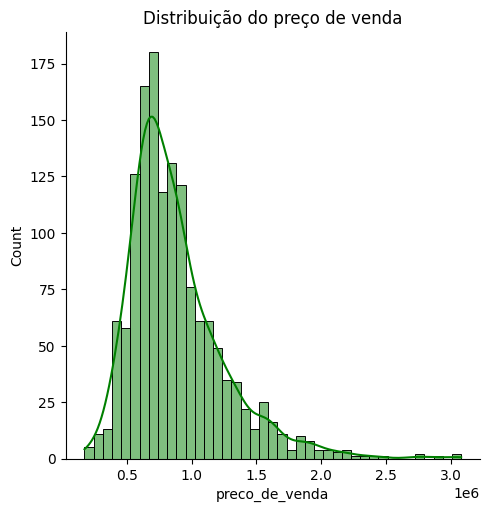

In [36]:
sns.displot(data['preco_de_venda'], kde=True, color='green')
plt.title('Distribuição do preço de venda')
plt.show()


##### Testando a acurácia do modelo

Nesse momento iremos validar a qualidade do modelo de dados medindo a taxa de acerto através da comparação entre os dados previstos e os dados de teste (que são os dados reais).


In [31]:
y_predict = modelo_0.predict(x_test)

In [33]:
from sklearn.metrics import r2_score

É importante que os R² dos dados de treino e o R² score do modelo de dados estejam próximos um do outro. isso indica que uma porcentagem dos preços das casas podem ser explicadas a partir da variável área do primeiro andar

In [34]:
print("R²", r2_score(y_teste,y_predict))

R² 0.38530928723202407


Sintese:

- Dividir a base de dados para treinar e testar o modelo;
- Interpretar os coeficientes de regressão linear simples;
- Calcular e interpretar o coeficiente de determinação R²;
- Analisar o quanto cada ponto de dados desvia da linha de regressão ajustada através dos resíduos;
- Compreender quão bem os valores observados se ajustam ao modelo de regressão com R²;
- Calcular o R² no conjunto teste.